# IS 362 Project 1

**Shehou Fisiru**

This notebook compares arrival delays for Alaska and AM West across five cities. I stored the data in a CSV in long format (one row per airline, city, and status) so it's easy to work with in pandas.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("airline_delays.csv")
df.head()

,airline,city,status,count
0,Alaska,Los Angeles,on time,497
1,Alaska,Los Angeles,delayed,62
2,Alaska,Phoenix,on time,221
3,Alaska,Phoenix,delayed,12
4,Alaska,San Diego,on time,212


## Delay rate by airline and city

I pivot so on time and delayed counts sit side by side, then calculate the delay rate (delayed / total).

In [ ]:
stats = df.pivot_table(index=["airline", "city"], columns="status", values="count").reset_index()
stats["total"] = stats["on time"] + stats["delayed"]
stats["delay_rate"] = stats["delayed"] / stats["total"]
stats

status,airline,city,delayed,on time,total,delay_rate
0,AM West,Los Angeles,117.0,694.0,811.0,0.144266
1,AM West,Phoenix,415.0,4840.0,5255.0,0.078972
2,AM West,San Diego,65.0,383.0,448.0,0.145089
3,AM West,San Francisco,129.0,320.0,449.0,0.287305
4,AM West,Seattle,61.0,201.0,262.0,0.232824
5,Alaska,Los Angeles,62.0,497.0,559.0,0.110912
6,Alaska,Phoenix,12.0,221.0,233.0,0.051502
7,Alaska,San Diego,20.0,212.0,232.0,0.086207
8,Alaska,San Francisco,102.0,503.0,605.0,0.168595
9,Alaska,Seattle,305.0,1841.0,2146.0,0.142125


## Overall comparison

In [ ]:
overall = stats.groupby("airline")[["delayed", "total"]].sum()
overall["delay_rate"] = overall["delayed"] / overall["total"]
overall

status,delayed,total,delay_rate
airline,,,
AM West,787.0,7225.0,0.108927
Alaska,501.0,3775.0,0.132715


Overall, AM West appears better, as about 10.9% of its flights were delayed compared to 13.3% for Alaska.

## City-by-city comparison

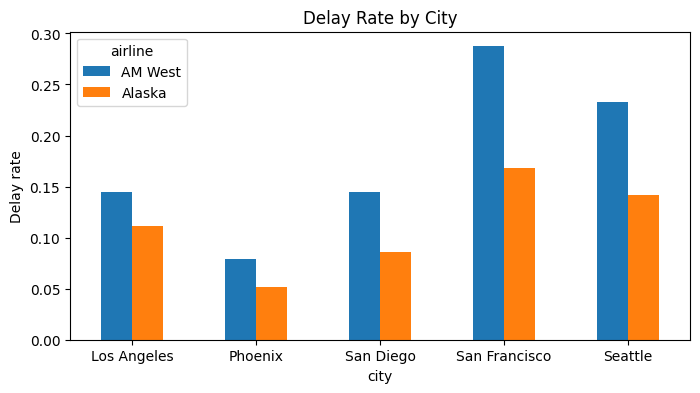

airline,AM West,Alaska
city,,
Los Angeles,0.144266,0.110912
Phoenix,0.078972,0.051502
San Diego,0.145089,0.086207
San Francisco,0.287305,0.168595
Seattle,0.232824,0.142125


In [ ]:
rates = stats.pivot(index="city", columns="airline", values="delay_rate")
rates.plot(kind="bar", rot=0, figsize=(8, 4), title="Delay Rate by City")
plt.ylabel("Delay rate")
plt.show()
rates

However, when broken down by city, Alaska has the lower delay rate in all five cities.

In [ ]:
stats.pivot(index="city", columns="airline", values="total")

airline,AM West,Alaska
city,,
Los Angeles,811.0,559.0
Phoenix,5255.0,233.0
San Diego,448.0,232.0
San Francisco,449.0,605.0
Seattle,262.0,2146.0


The reason for this is due to where each airline flies. Most of AM West's flights (about 73%) go to Phoenix, which has the lowest delay rates of any city. Most of Alaska's flights go to Seattle, which has much higher delays. AM West's overall number looks good because of its route mix, not because it performs better.


## Conclusion

Alaska is the better airline for on-time arrivals. It beats AM West in every city, and AM West's better overall rate is only a result of flying mostly to Phoenix. It's worth breaking data into groups to avoid drawing false conclusions.